# Zomato Restaurant Data Analysis

## Project Objective

The objective of this project is to analyze restaurant data from Zomato and identify patterns related to ratings, costs, cuisines, restaurant types, and customer preferences.

### Tools Used
- Python
- Pandas
- Matplotlib
- Seaborn

### Dataset
- 51,717 restaurant records
- Multiple restaurant attributes including ratings, votes, location, cuisine, and pricing


In [1]:
# Importing Required Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# import dataset 
df = pd.read_csv("../data/zomato.csv", encoding='latin-1')

# shape of dataset
print("shape: ", df.shape)

shape:  (51717, 17)


# Initial Data Exploration

Understanding the structure of the dataset.

In [5]:
# gives top five rows of dataset
df.head()


,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [6]:
# information about dataset 
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list                 51

In [7]:
# getting stats
df.describe()
# df.describe(include='all')
# df.describe(include='object')


,votes
count,51717.000000
mean,283.697527
std,803.838853
min,0.000000
25%,7.000000
50%,41.000000
75%,198.000000
max,16832.000000


# Missing Value Analysis

Identifying columns with missing values and deciding appropriate handling strategies.

In [8]:
# finds nan values and thei sum from each column
df.isnull().sum()


url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

# analysis of unique values 

In [9]:
print("Online Order:", df['online_order'].unique())
print("Book Table:", df['book_table'].unique())
print("Rate:", df['rate'].unique()[:10])
print("Total Locations:", df['location'].nunique())
print("Total Cuisines:", df['cuisines'].nunique())
print("Restaurant Types:", df['rest_type'].nunique())
print("Types:", df['listed_in(type)'].unique())


Online Order: ['Yes' 'No']
Book Table: ['Yes' 'No']
Rate: ['4.1/5' '3.8/5' '3.7/5' '3.6/5' '4.6/5' '4.0/5' '4.2/5' '3.9/5' '3.1/5'
 '3.0/5']
Total Locations: 93
Total Cuisines: 2723
Restaurant Types: 93
Types: ['Buffet' 'Cafes' 'Delivery' 'Desserts' 'Dine-out' 'Drinks & nightlife'
 'Pubs and bars']


# Cleaning Restaurant Ratings

Steps:
1. Remove NEW values
2. Remove '-' values
3. Remove missing values
4. Convert ratings into numerical format

In [10]:
df = df[(df['rate'] != "NEW") & (df['rate'] != '-')]
df['rate'].shape


(49440,)

In [11]:
(df['rate'] == 'NEW').sum()


np.int64(0)

In [12]:
(df['rate'] == '-').sum()


np.int64(0)

In [13]:
df['rate'].isnull().sum()


np.int64(7775)

In [14]:
# total rows = 51717
# "NEW" + "-" = 2277
# null values = 7775
remainig_rows = 51717 - (7775+2277)
remainig_rows

41665

In [15]:
df = df[~df['rate'].isnull()]
df['rate'].isnull().sum()

np.int64(0)

In [16]:
df['rate'].unique()

array(['4.1/5', '3.8/5', '3.7/5', '3.6/5', '4.6/5', '4.0/5', '4.2/5',
       '3.9/5', '3.1/5', '3.0/5', '3.2/5', '3.3/5', '2.8/5', '4.4/5',
       '4.3/5', '2.9/5', '3.5/5', '2.6/5', '3.8 /5', '3.4/5', '4.5/5',
       '2.5/5', '2.7/5', '4.7/5', '2.4/5', '2.2/5', '2.3/5', '3.4 /5',
       '3.6 /5', '4.8/5', '3.9 /5', '4.2 /5', '4.0 /5', '4.1 /5',
       '3.7 /5', '3.1 /5', '2.9 /5', '3.3 /5', '2.8 /5', '3.5 /5',
       '2.7 /5', '2.5 /5', '3.2 /5', '2.6 /5', '4.5 /5', '4.3 /5',
       '4.4 /5', '4.9/5', '2.1/5', '2.0/5', '1.8/5', '4.6 /5', '4.9 /5',
       '3.0 /5', '4.8 /5', '2.3 /5', '4.7 /5', '2.4 /5', '2.1 /5',
       '2.2 /5', '2.0 /5', '1.8 /5'], dtype=object)

In [17]:
df['rate'] = df['rate'].str.replace("/5",'')
df['rate'].unique()

array(['4.1', '3.8', '3.7', '3.6', '4.6', '4.0', '4.2', '3.9', '3.1',
       '3.0', '3.2', '3.3', '2.8', '4.4', '4.3', '2.9', '3.5', '2.6',
       '3.8 ', '3.4', '4.5', '2.5', '2.7', '4.7', '2.4', '2.2', '2.3',
       '3.4 ', '3.6 ', '4.8', '3.9 ', '4.2 ', '4.0 ', '4.1 ', '3.7 ',
       '3.1 ', '2.9 ', '3.3 ', '2.8 ', '3.5 ', '2.7 ', '2.5 ', '3.2 ',
       '2.6 ', '4.5 ', '4.3 ', '4.4 ', '4.9', '2.1', '2.0', '1.8', '4.6 ',
       '4.9 ', '3.0 ', '4.8 ', '2.3 ', '4.7 ', '2.4 ', '2.1 ', '2.2 ',
       '2.0 ', '1.8 '], dtype=object)

In [18]:
df['rate'] = df['rate'].str.strip()
df['rate'].unique()

array(['4.1', '3.8', '3.7', '3.6', '4.6', '4.0', '4.2', '3.9', '3.1',
       '3.0', '3.2', '3.3', '2.8', '4.4', '4.3', '2.9', '3.5', '2.6',
       '3.4', '4.5', '2.5', '2.7', '4.7', '2.4', '2.2', '2.3', '4.8',
       '4.9', '2.1', '2.0', '1.8'], dtype=object)

In [19]:
df['rate'] = df['rate'].astype("float64")

In [20]:
df['rate'].dtype

dtype('float64')

In [21]:
df['rate'].describe()

count    41665.000000
mean         3.700449
std          0.440513
min          1.800000
25%          3.400000
50%          3.700000
75%          4.000000
max          4.900000
Name: rate, dtype: float64

# Cleaning Cost Information

Steps:
1. Handle missing values
2. Remove commas from cost values
3. Convert to numeric datatype

In [22]:
df['approx_cost(for two people)'].isnull().sum()

np.int64(247)

In [23]:
df = df[~df['approx_cost(for two people)'].isnull()]
df['approx_cost(for two people)'].isnull().sum()

np.int64(0)

In [24]:
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].str.replace(',','')
df['approx_cost(for two people)'].unique()

array(['800', '300', '600', '700', '550', '500', '450', '650', '400',
       '900', '200', '750', '150', '850', '100', '1200', '350', '250',
       '950', '1000', '1500', '1300', '199', '1100', '1600', '230', '130',
       '1700', '1350', '2200', '1400', '2000', '1800', '1900', '180',
       '330', '2500', '2100', '3000', '2800', '3400', '50', '40', '1250',
       '3500', '4000', '2400', '2600', '1450', '70', '3200', '240',
       '6000', '1050', '2300', '4100', '120', '5000', '3700', '1650',
       '2700', '4500', '80'], dtype=object)

In [25]:
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype('int64')


In [26]:
print("data type: ", df['approx_cost(for two people)'].dtype)
print("\nunique: ", df['approx_cost(for two people)'].unique())
print("\ndescribe: ", df['approx_cost(for two people)'].describe())

data type:  int64

unique:  [ 800  300  600  700  550  500  450  650  400  900  200  750  150  850
  100 1200  350  250  950 1000 1500 1300  199 1100 1600  230  130 1700
 1350 2200 1400 2000 1800 1900  180  330 2500 2100 3000 2800 3400   50
   40 1250 3500 4000 2400 2600 1450   70 3200  240 6000 1050 2300 4100
  120 5000 3700 1650 2700 4500   80]

describe:  count    41418.000000
mean       603.268048
std        464.327857
min         40.000000
25%        300.000000
50%        500.000000
75%        700.000000
max       6000.000000
Name: approx_cost(for two people), dtype: float64


In [27]:
# rename approx_cost(for two people) as approx_cost 
df.rename(columns={'approx_cost(for two people)':'approx_cost'},inplace=True)

In [28]:
df_original = df.copy()
df_original.shape

(41418, 17)

# Feature Selection

Removing irrelevant columns that do not contribute to business analysis.

In [29]:
df = df.drop(['url',
'phone',
'reviews_list',
'menu_item',
'listed_in(city)',
'address',
'dish_liked'],axis=1)

In [30]:
df.shape

(41418, 10)

In [31]:
df.columns.to_list()

['name',
 'online_order',
 'book_table',
 'rate',
 'votes',
 'location',
 'rest_type',
 'cuisines',
 'approx_cost',
 'listed_in(type)']

In [32]:
df.isnull().sum()

name                 0
online_order         0
book_table           0
rate                 0
votes                0
location             0
rest_type          147
cuisines             8
approx_cost          0
listed_in(type)      0
dtype: int64

# handling missing values from all columns

In [33]:
df = df[~df['rest_type'].isnull()]
df['rest_type'].isnull().sum()

np.int64(0)

In [34]:
df = df[~df['cuisines'].isnull()]
df['cuisines'].isnull().sum()

np.int64(0)

In [35]:
df.isnull().sum()

name               0
online_order       0
book_table         0
rate               0
votes              0
location           0
rest_type          0
cuisines           0
approx_cost        0
listed_in(type)    0
dtype: int64

# Exploratory Data Analysis (EDA)

Analyzing distributions of:
- Online ordering
- Table booking
- Locations
- Restaurant types
- Cuisines

In [36]:
df['online_order'].value_counts()

online_order
Yes    27102
No     14161
Name: count, dtype: int64

In [37]:
df['book_table'].value_counts()

book_table
No     34959
Yes     6304
Name: count, dtype: int64

In [38]:
df['rest_type'].value_counts().head(10)

rest_type
Quick Bites           13885
Casual Dining          9614
Cafe                   3369
Dessert Parlor         1850
Delivery               1667
Takeaway, Delivery     1279
Casual Dining, Bar     1092
Bakery                  704
Bar                     640
Beverage Shop           640
Name: count, dtype: int64

In [39]:
df['location'].value_counts().head(10)

location
BTM                      3879
Koramangala 5th Block    2297
HSR                      1993
Indiranagar              1800
JP Nagar                 1710
Jayanagar                1634
Whitefield               1568
Marathahalli             1410
Bannerghatta Road        1226
Koramangala 7th Block    1055
Name: count, dtype: int64

In [40]:
df['cuisines'].value_counts().head(10)

cuisines
North Indian                           2108
North Indian, Chinese                  1953
South Indian                           1232
Cafe                                    620
Bakery, Desserts                        613
Biryani                                 600
South Indian, North Indian, Chinese     561
Desserts                                545
Fast Food                               514
Chinese                                 410
Name: count, dtype: int64

In [41]:
df.groupby('online_order')['rate'].mean()

online_order
No     3.660031
Yes    3.723947
Name: rate, dtype: float64

In [42]:
df.groupby('book_table')['rate'].mean()

book_table
No     3.622406
Yes    4.143464
Name: rate, dtype: float64

In [43]:
df.groupby('location')['rate'].mean().sort_values(ascending=False).head(10)

location
Lavelle Road             4.141788
Koramangala 3rd Block    4.020419
St. Marks Road           4.017201
Koramangala 5th Block    4.006661
Church Street            3.992125
Sankey Road              3.965385
Koramangala 4th Block    3.918668
Cunningham Road          3.901053
Residency Road           3.864570
Koramangala 7th Block    3.852986
Name: rate, dtype: float64

In [44]:
df.groupby('rest_type')['rate'].mean().sort_values(ascending=False).head(10)

rest_type
Pub, Cafe                      4.657500
Bar, Pub                       4.600000
Microbrewery                   4.478571
Pub, Microbrewery              4.452632
Microbrewery, Bar              4.446154
Microbrewery, Pub              4.438095
Casual Dining, Irani Cafee     4.406667
Cafe, Lounge                   4.400000
Fine Dining, Lounge            4.400000
Microbrewery, Casual Dining    4.369421
Name: rate, dtype: float64

In [45]:
df.groupby('location')['approx_cost'].mean().sort_values(ascending=False).head(10)

location
Sankey Road         2582.692308
Lavelle Road        1365.384615
Race Course Road    1321.481481
MG Road             1244.514502
Infantry Road       1072.857143
Residency Road      1030.049669
Richmond Road        903.228477
St. Marks Road       883.673469
Langford Town        883.333333
Cunningham Road      867.157895
Name: approx_cost, dtype: float64

In [46]:
df.groupby('location')['rate'].count().sort_values(ascending=False)

location
BTM                      3879
Koramangala 5th Block    2297
HSR                      1993
Indiranagar              1800
JP Nagar                 1710
                         ... 
Yelahanka                   4
West Bangalore              3
Rajarajeshwari Nagar        2
Nagarbhavi                  1
Peenya                      1
Name: rate, Length: 92, dtype: int64

# Final Cleaned Dataset

The dataset is now fully cleaned and ready for analysis.

In [47]:
print("Final Shape:", df.shape)
print("\nMissing Values:\n")
print(df.isnull().sum())

Final Shape: (41263, 10)

Missing Values:

name               0
online_order       0
book_table         0
rate               0
votes              0
location           0
rest_type          0
cuisines           0
approx_cost        0
listed_in(type)    0
dtype: int64


# Data Visualization

Visualizing restaurant trends and customer behavior.

C:\Users\sudha\AppData\Local\Temp\ipykernel_17812\1420548052.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


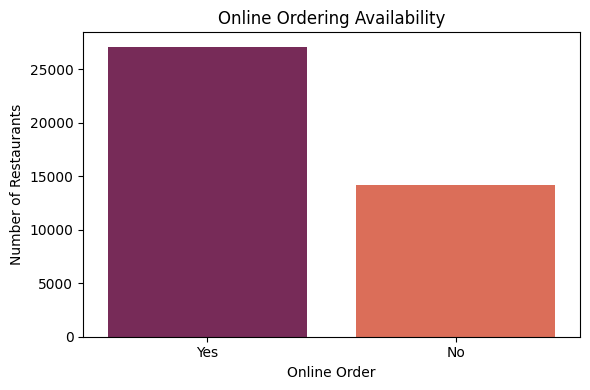

In [48]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='online_order',
    data=df,
    palette='rocket'
)

plt.title('Online Ordering Availability')
plt.xlabel('Online Order')
plt.ylabel('Number of Restaurants')

plt.tight_layout()
plt.show()

C:\Users\sudha\AppData\Local\Temp\ipykernel_17812\970304697.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


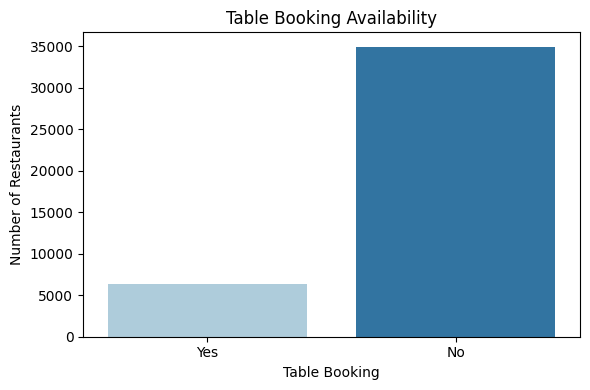

In [49]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='book_table',
    data=df,
    palette='Paired'
)

plt.title('Table Booking Availability')
plt.xlabel('Table Booking')
plt.ylabel('Number of Restaurants')

plt.tight_layout()
plt.show()

C:\Users\sudha\AppData\Local\Temp\ipykernel_17812\1133700801.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


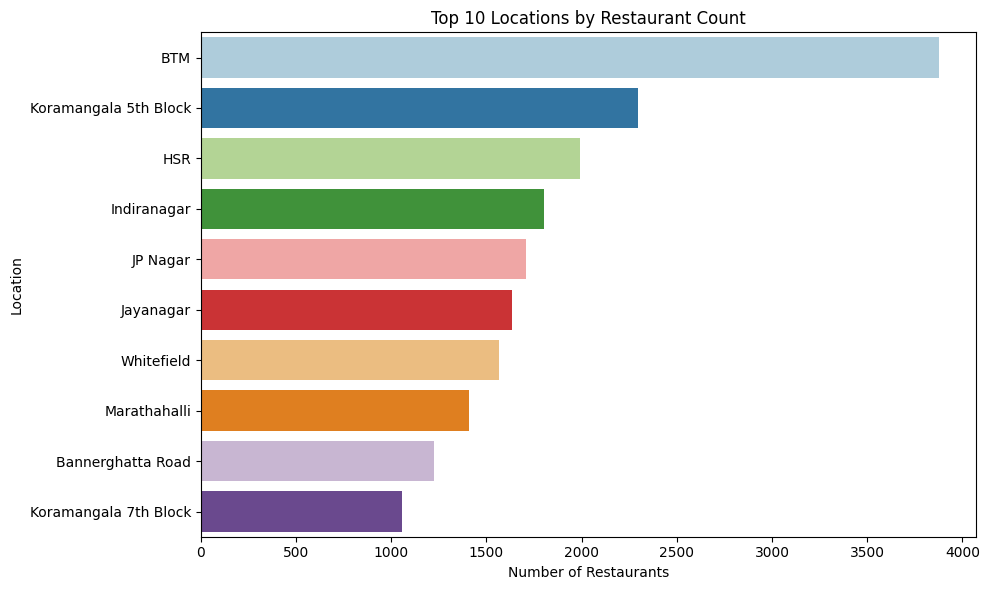

In [50]:
top_locations = df['location'].value_counts().head(10)
plt.figure(figsize=(10,6))

sns.barplot(
    x=top_locations.values,
    y=top_locations.index,
    palette='Paired'
)

plt.title('Top 10 Locations by Restaurant Count')
plt.xlabel('Number of Restaurants')
plt.ylabel('Location')

plt.tight_layout()
plt.show()

C:\Users\sudha\AppData\Local\Temp\ipykernel_17812\3174709088.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


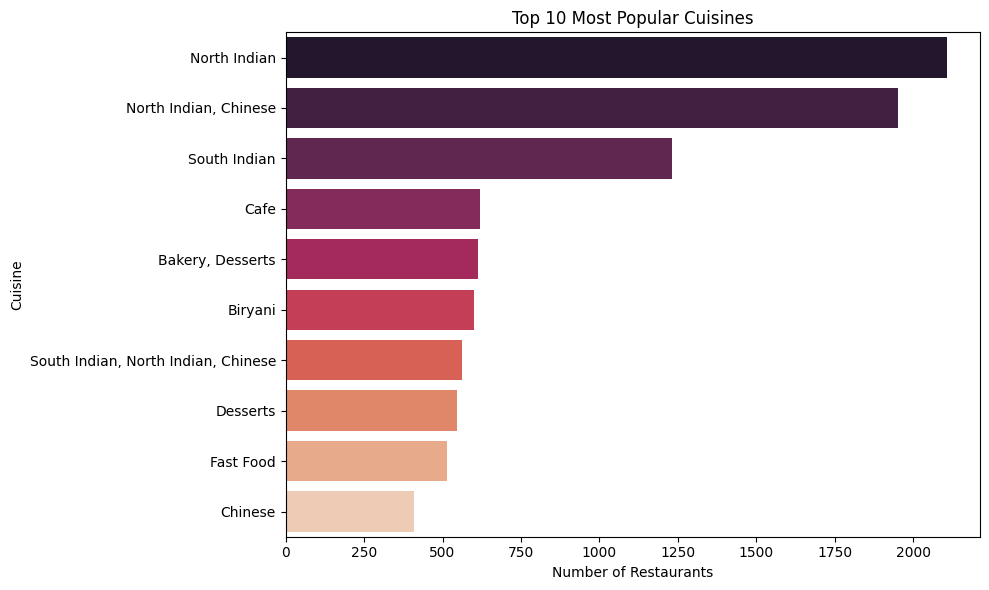

In [51]:
top_cuisines = df['cuisines'].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_cuisines.values,
    y=top_cuisines.index,
    palette='rocket'
)

plt.title('Top 10 Most Popular Cuisines')
plt.xlabel('Number of Restaurants')
plt.ylabel('Cuisine')

plt.tight_layout()
plt.show()

C:\Users\sudha\AppData\Local\Temp\ipykernel_17812\386897397.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


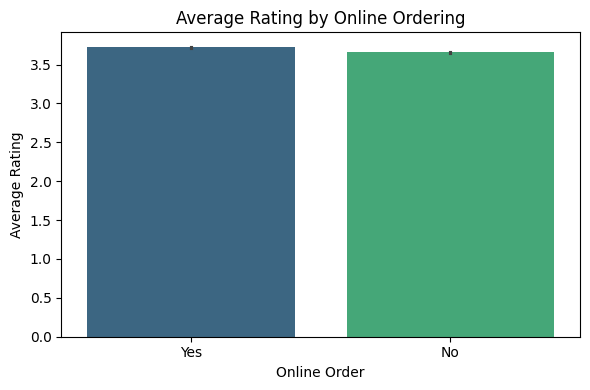

In [52]:
plt.figure(figsize=(6,4))

sns.barplot(
    x='online_order',
    y='rate',
    data=df,
    palette='viridis'
)

plt.title('Average Rating by Online Ordering')
plt.xlabel('Online Order')
plt.ylabel('Average Rating')

plt.tight_layout()
plt.show()

C:\Users\sudha\AppData\Local\Temp\ipykernel_17812\204368688.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


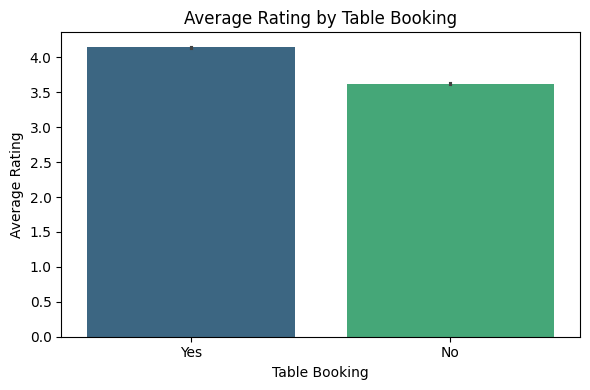

In [53]:
plt.figure(figsize=(6,4))

sns.barplot(
    x='book_table',
    y='rate',
    data=df,
    palette='viridis'
)

plt.title('Average Rating by Table Booking')
plt.xlabel('Table Booking')
plt.ylabel('Average Rating')

plt.tight_layout()
plt.show()

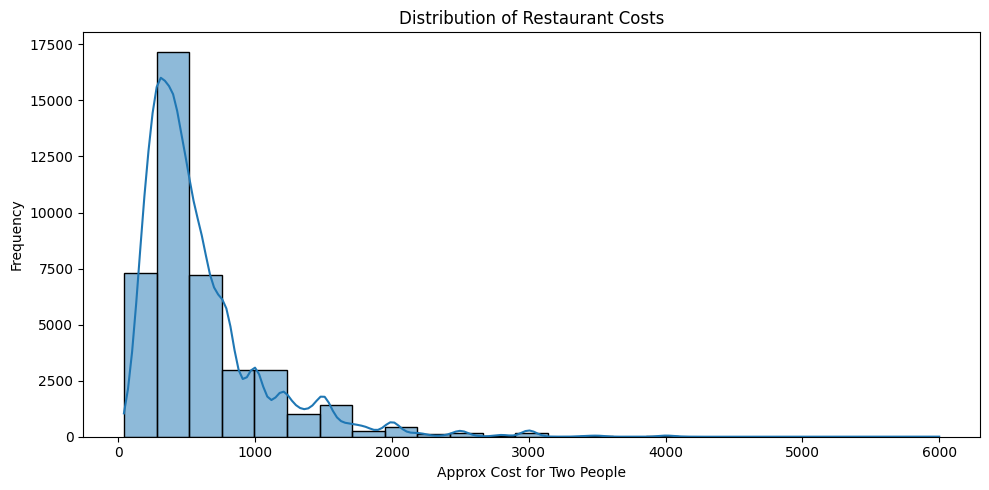

In [54]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['approx_cost'],
    bins=25,
    kde=True
)

plt.title('Distribution of Restaurant Costs')
plt.xlabel('Approx Cost for Two People')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

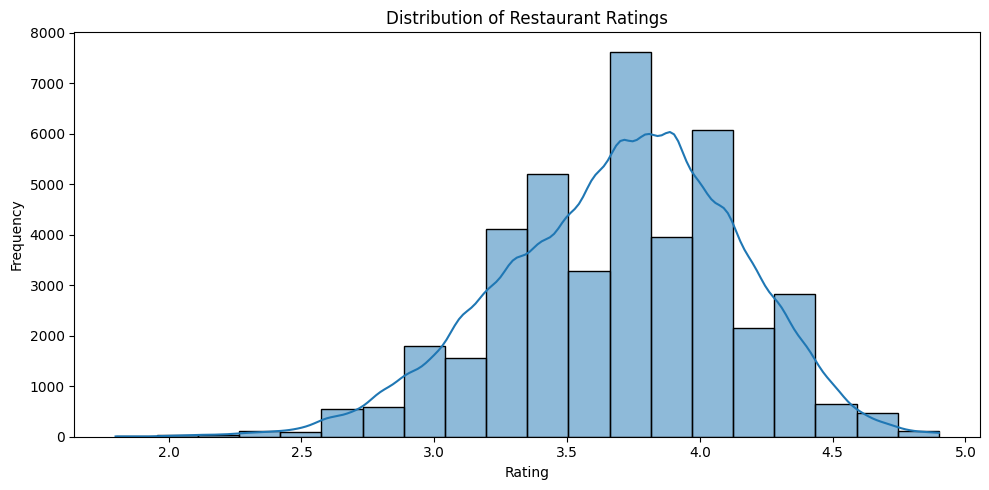

In [55]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['rate'],
    bins=20,
    kde=True
)

plt.title('Distribution of Restaurant Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [56]:
location_stats = df.groupby('location')['rate'].agg(['mean','count'])
location_stats = location_stats[location_stats['count'] > 100]
location_stats = location_stats.sort_values(by='mean', ascending=False)
top_locations = location_stats.head(10)
top_locations

,mean,count
location,,
Lavelle Road,4.141788,481
Koramangala 3rd Block,4.020419,191
St. Marks Road,4.017201,343
Koramangala 5th Block,4.006661,2297
Church Street,3.992125,546
Koramangala 4th Block,3.918668,841
Cunningham Road,3.901053,475
Residency Road,3.864570,604
Koramangala 7th Block,3.852986,1055


C:\Users\sudha\AppData\Local\Temp\ipykernel_17812\743991577.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


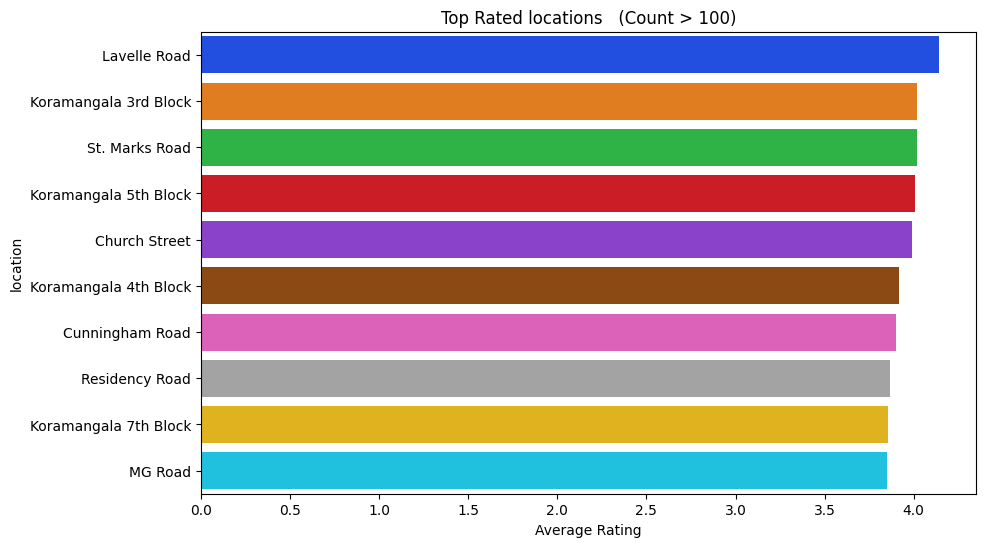

In [57]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='mean',
    y=top_locations.index,
    data=top_locations,
    palette="bright"
)

plt.title('Top Rated locations   (Count > 100)')
plt.xlabel('Average Rating')
plt.ylabel('location')
plt.show()

In [58]:
rest_type_stats = df.groupby('rest_type')['rate'].agg(['mean','count'])
rest_type_stats = rest_type_stats[rest_type_stats['count'] > 50]
rest_type_stats = rest_type_stats.sort_values(by='mean',ascending=False)
top_rests = rest_type_stats.head(10)
top_rests

,mean,count
rest_type,,
"Pub, Microbrewery",4.452632,76
"Microbrewery, Casual Dining",4.369421,121
"Casual Dining, Cafe",4.196129,310
"Casual Dining, Pub",4.178740,127
Fine Dining,4.150146,343
"Cafe, Dessert Parlor",4.147222,144
"Dessert Parlor, Cafe",4.136806,144
"Bar, Casual Dining",4.125195,385
"Pub, Casual Dining",4.092373,236


C:\Users\sudha\AppData\Local\Temp\ipykernel_17812\684291965.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


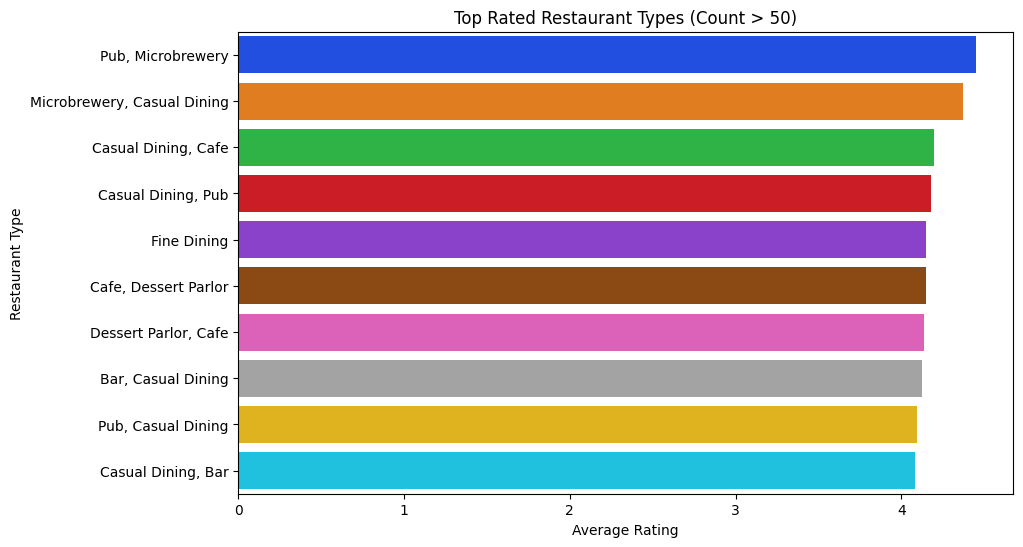

In [59]:
plt.figure(figsize=(10,6))
sns.barplot(
    x='mean',
    y=top_rests.index,
    data=top_rests,
    palette="bright"
    
)
plt.title('Top Rated Restaurant Types (Count > 50)')
plt.xlabel('Average Rating')
plt.ylabel('Restaurant Type')

plt.show()

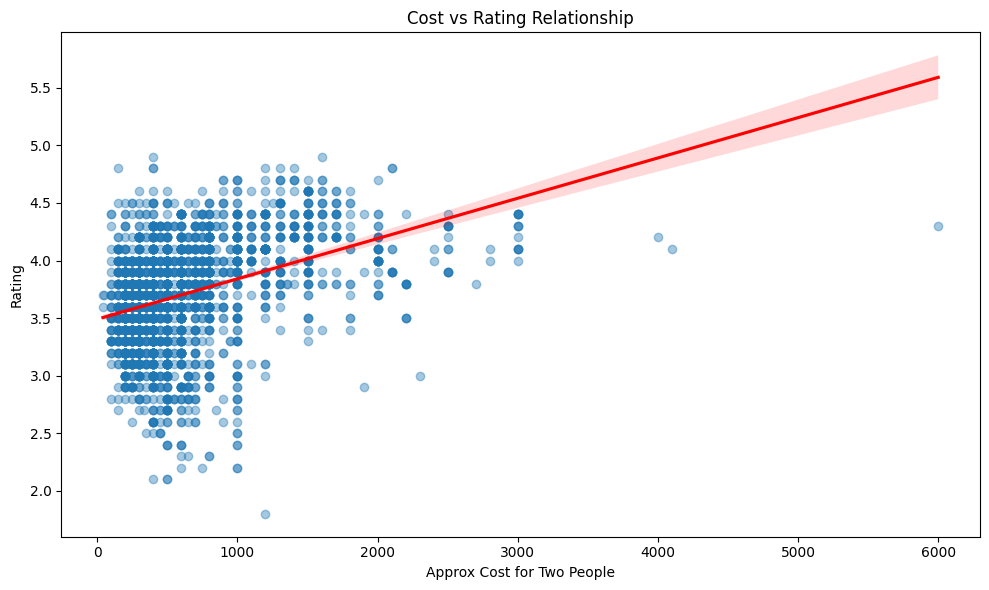

In [60]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=df.sample(3000),
    x='approx_cost',
    y='rate',
    scatter_kws={'alpha':0.4},
    line_kws={'color':'red'}
)

plt.title('Cost vs Rating Relationship')
plt.xlabel('Approx Cost for Two People')
plt.ylabel('Rating')

plt.tight_layout()
plt.show()

# Correlation Analysis

Examining relationships between:
- Ratings
- Votes
- Approximate Cost

In [61]:
df[['rate','votes','approx_cost']].corr()

,rate,votes,approx_cost
rate,1.000000,0.435256,0.385384
votes,0.435256,1.000000,0.366556
approx_cost,0.385384,0.366556,1.000000


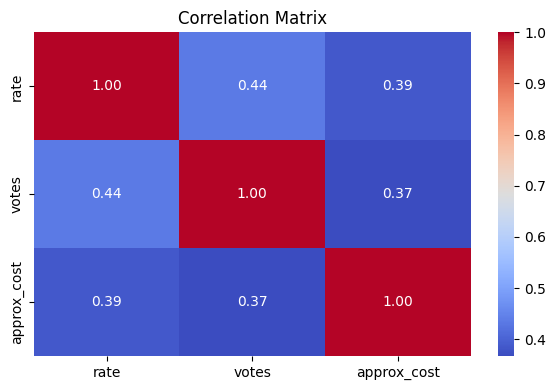

In [62]:
plt.figure(figsize=(6,4))

sns.heatmap(
    df[['rate','votes','approx_cost']].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')

plt.tight_layout()
plt.show()

In [63]:
df[['name','votes','rate']]\
.sort_values(
    by='votes',
    ascending=False
).head(10)

,name,votes,rate
49170,Byg Brewski Brewing Company,16832,4.9
49627,Byg Brewski Brewing Company,16832,4.9
50059,Byg Brewski Brewing Company,16832,4.9
4944,Byg Brewski Brewing Company,16345,4.9
4801,Byg Brewski Brewing Company,16345,4.9
3921,Byg Brewski Brewing Company,16345,4.9
19268,Toit,14956,4.7
18643,Toit,14956,4.7
36668,Truffles,14726,4.7
34779,Truffles,14723,4.7


In [64]:
df[df['votes'] > 100].sort_values(
    by='rate',
    ascending=False)[['name','rate','votes']].head(10)

,name,rate,votes
21279,AB's - Absolute Barbecues,4.9,6452
6746,Flechazo,4.9,2745
49627,Byg Brewski Brewing Company,4.9,16832
46960,Punjab Grill,4.9,1985
11745,Belgian Waffle Factory,4.9,1744
34734,Asia Kitchen By Mainland China,4.9,2249
33932,Asia Kitchen By Mainland China,4.9,2249
36684,Asia Kitchen By Mainland China,4.9,2254
50059,Byg Brewski Brewing Company,4.9,16832
29271,Asia Kitchen By Mainland China,4.9,2235


In [65]:
top_votes = (
    df.groupby('name')['votes']
    .max()
    .sort_values(ascending=False)
    .head(10)
)

C:\Users\sudha\AppData\Local\Temp\ipykernel_17812\1771416201.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


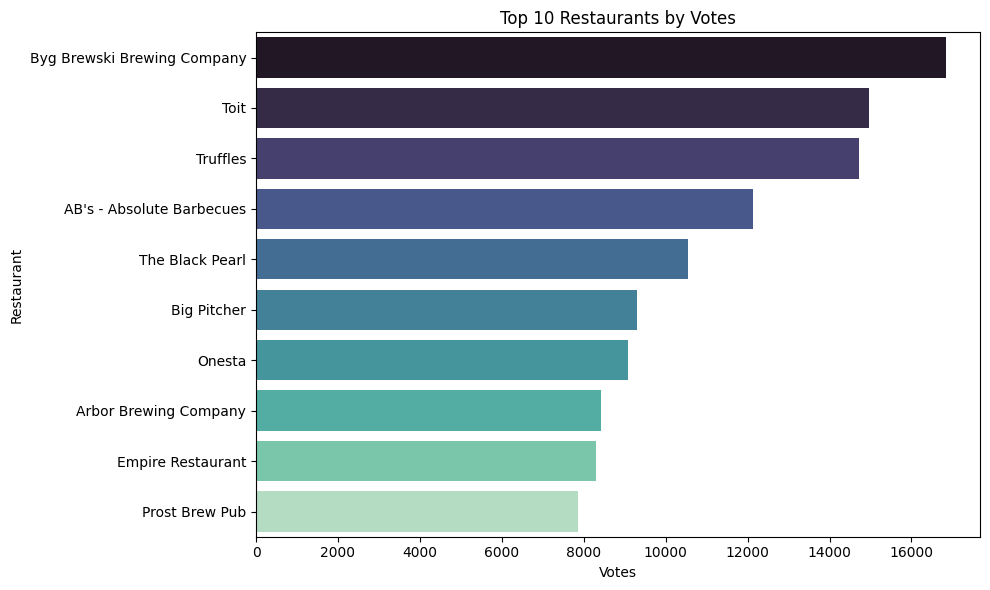

In [66]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=top_votes.values,
    y=top_votes.index,
    palette='mako'
)

plt.title('Top 10 Restaurants by Votes')
plt.xlabel('Votes')
plt.ylabel('Restaurant')

plt.tight_layout()
plt.show()

In [67]:
top_rests.head(10)

,mean,count
rest_type,,
"Pub, Microbrewery",4.452632,76
"Microbrewery, Casual Dining",4.369421,121
"Casual Dining, Cafe",4.196129,310
"Casual Dining, Pub",4.178740,127
Fine Dining,4.150146,343
"Cafe, Dessert Parlor",4.147222,144
"Dessert Parlor, Cafe",4.136806,144
"Bar, Casual Dining",4.125195,385
"Pub, Casual Dining",4.092373,236


# Key Business Insights

1. Approximately 66% of restaurants support online ordering.

2. Only 15% of restaurants provide table booking facilities.

3. Restaurants offering table booking achieve an average rating of 4.14 compared to 3.62 for those that don't — a difference of 0.52 points, suggesting table booking is associated with higher quality dining experiences.

4. North Indian cuisine dominates the restaurant market.

5. BTM has the highest restaurant concentration.

6. Lavelle Road achieved the highest average restaurant rating of 4.14 among locations with more than 100 restaurants, followed by Koramangala 3rd Block (4.02) and St. Marks Road (4.02). This suggests that premium commercial areas tend to host higher-rated dining establishments.

7. Among restaurant types with at least 50 observations, Pub, Microbrewery achieved the highest average rating of approximately 4.45, followed by Microbrewery, Casual Dining (4.36) and Casual Dining, Cafe (4.19). Experience-oriented dining formats consistently received higher customer ratings than quick-service formats.

8. Most restaurants fall within the ₹300–₹700 price range.

9. Restaurant ratings and votes show a moderate positive relationship.

10. Higher-priced restaurants tend to receive slightly higher ratings.

In [68]:
df.to_csv("zomato_cleaned.csv", index=False)